<a href="https://colab.research.google.com/github/Pranayshukla0610/MLOPS-Project/blob/main/MLOPS_ANN_Model_On_CreditCard_Fraud_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
def load_data():
  url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

  os.makedirs("data", exist_ok=True)
  file_path = "data/creditcard.csv"

  if not os.path.exists(file_path):
    df = pd.read_csv(url)
    df.to_csv(file_path, index=False)
  else:
    df = pd.read_csv(file_path)

  return df

In [ ]:
%matplotlib inline

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

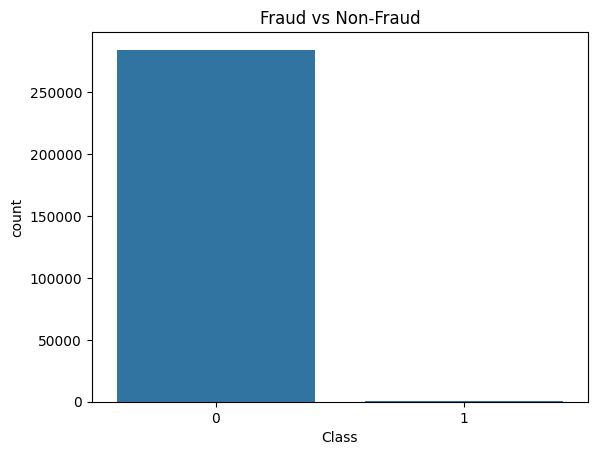

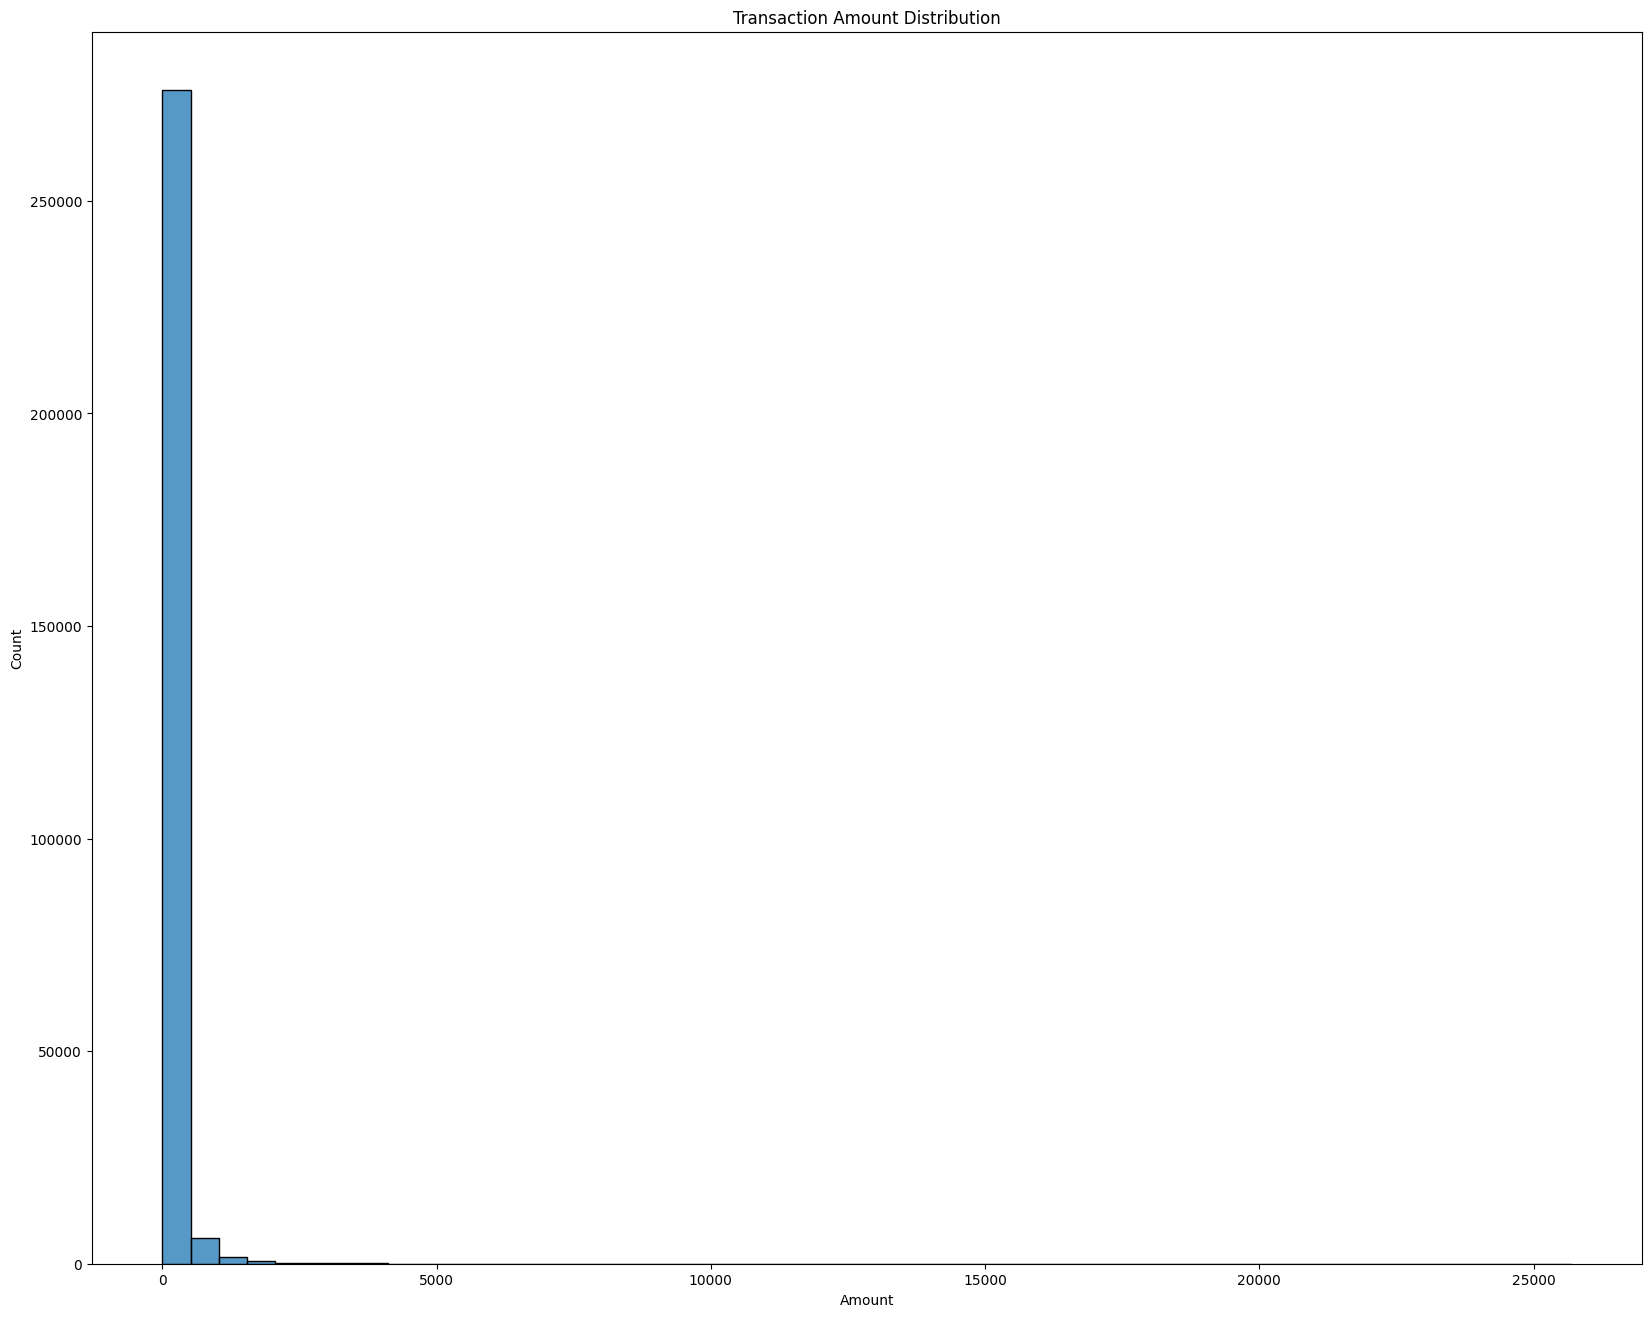

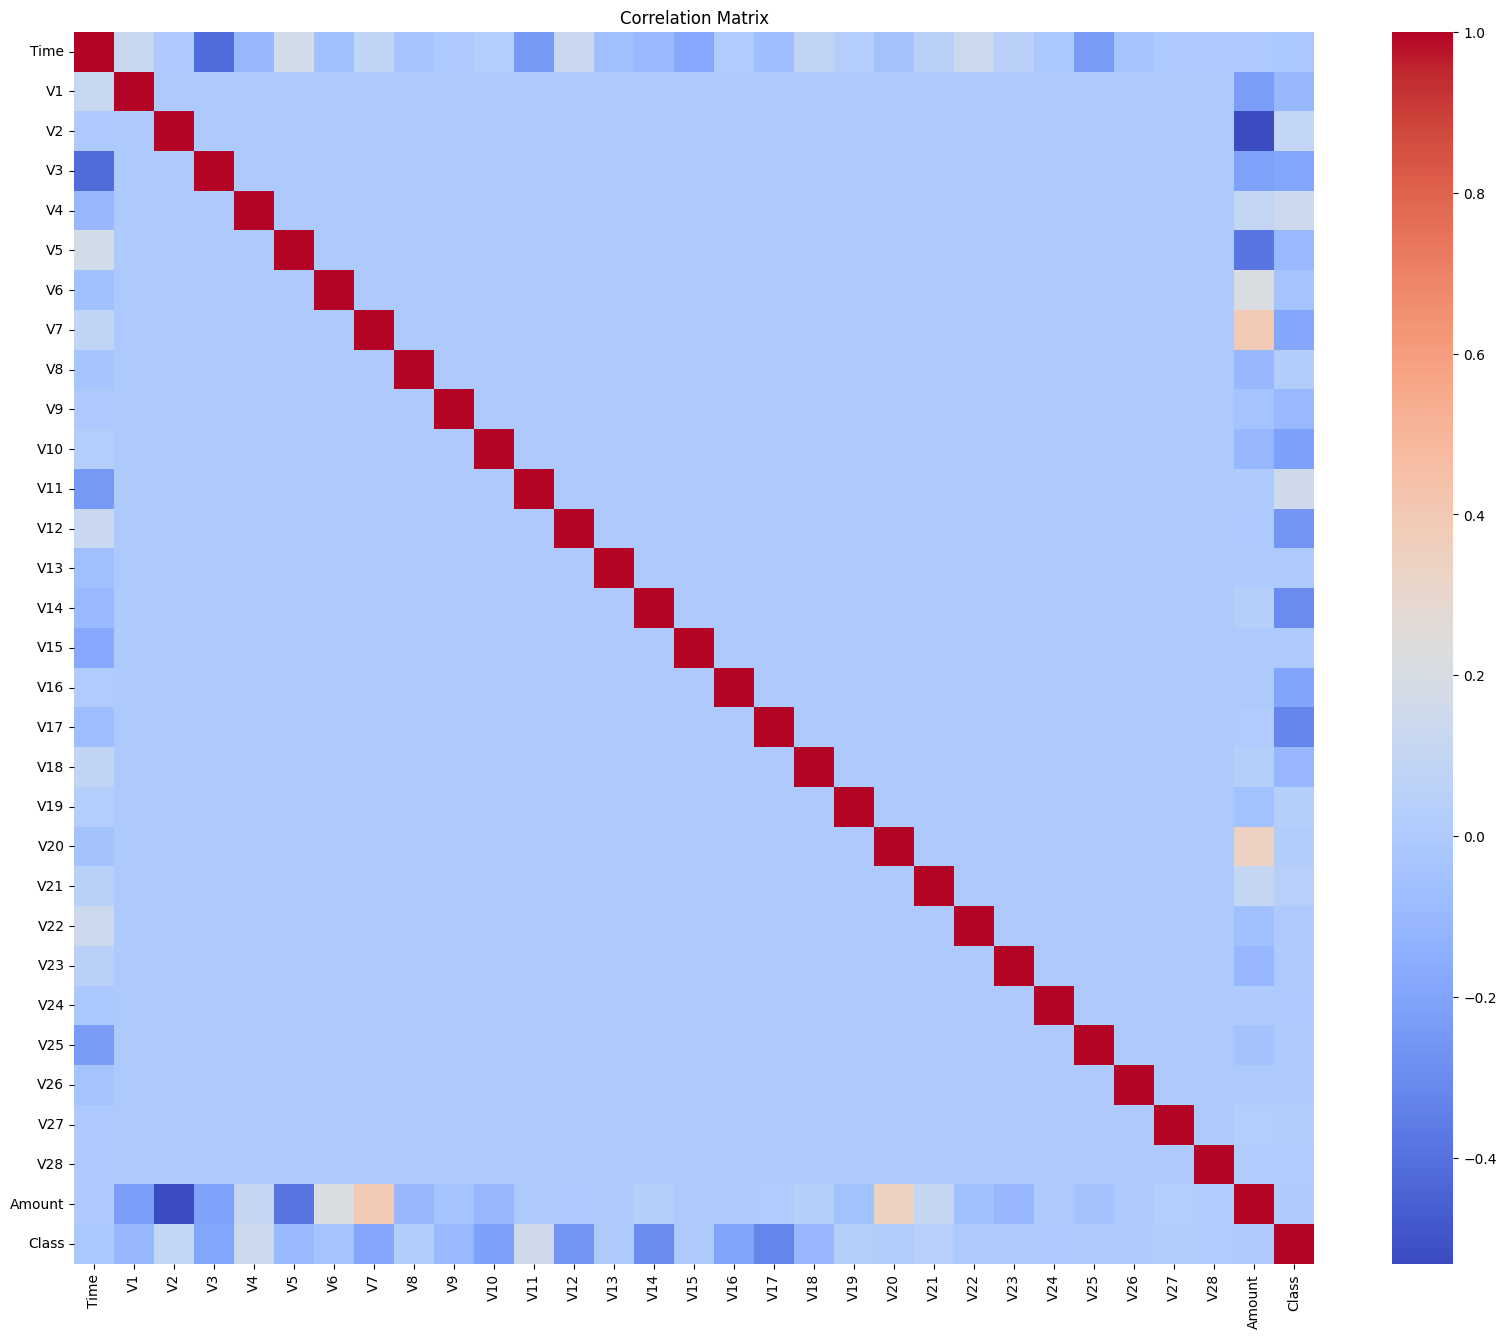

In [ ]:
def perform_eda(df):
  print(df.head())
  print(df.info())

  sns.countplot(x='Class', data=df)
  plt.title("Fraud vs Non-Fraud")
  plt.show()

  plt.figure(figsize=(20,16))
  sns.histplot(df['Amount'], bins=50)
  plt.title("Transaction Amount Distribution")
  plt.show()

  plt.figure(figsize=(20,16))
  sns.heatmap(df.corr(), cmap='coolwarm')
  plt.title('Correlation Matrix')
  plt.show()

df = load_data()

perform_eda(df)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preprocess_df(df):
  X = df.drop('Class',axis=1)
  y = df['Class']

  scaler = StandardScaler()
  X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])

  X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

  return X_train, X_test, y_train, y_test

In [ ]:

from sklearn.utils import resample

def handle_imbalance(X, y):

    # Combine
    df = X.copy()
    df["Class"] = y

    # Separate classes
    fraud = df[df.Class == 1]
    normal = df[df.Class == 0]

    # Downsample majority
    normal_downsampled = resample(
        normal,
        replace=False,
        n_samples=len(fraud)*5,
        random_state=42
    )

    df_balanced = pd.concat([fraud, normal_downsampled])

    X_bal = df_balanced.drop("Class", axis=1)
    y_bal = df_balanced["Class"]

    return X_bal, y_bal

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
def build_model(input_dim):
  model = Sequential()

  model.add(Dense(64, activation='relu', input_dim=input_dim))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))

  model.add(Dense(32, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))

  model.add(Dense(16, activation='relu'))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(
      optimizer='adam',
      loss = 'binary_crossentropy',
      metrics = ['accuracy']
  )
  return model

In [ ]:
import os
print(os.listdir())

['.config', 'data', 'sample_data']


In [ ]:
os.makedirs("src", exist_ok=True)

In [ ]:
# data_loader.py
with open("src/data_loader.py", "w") as f:
    f.write("""
import pandas as pd
import os

def load_data():
    url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
    os.makedirs("data", exist_ok=True)
    file_path = "data/creditcard.csv"

    if not os.path.exists(file_path):
        df = pd.read_csv(url)
        df.to_csv(file_path, index=False)
    else:
        df = pd.read_csv(file_path)

    return df
""")

In [ ]:
# train.py
with open("src/train.py", "w") as f:
    f.write("""
from src.data_loader import load_data

def train():
    df = load_data()
    print(df.shape)
    return df

if __name__ == "__main__":
    train()
""")

In [ ]:
for root, dirs, files in os.walk(".", topdown=True):
    print(root)

.
./.config
./.config/configurations
./.config/logs
./.config/logs/2026.04.02
./data
./src
./sample_data


In [ ]:
open("src/__init__.py", "w").close()

In [ ]:
import sys, os
sys.path.append(os.getcwd())

from src.train import train

train()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
import sys
import os

sys.path.append(os.path.abspath("."))

In [ ]:
os.makedirs("src.preprocessing", exist_ok=True)

In [ ]:
with open("src/preprocessing.py", "w") as f:
    f.write("""
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def preprocess_data(df):
    X = df.drop('Class', axis=1)
    y = df['Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test


def handle_imbalance(X, y):
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res
""")

In [ ]:
with open("src/model.py", "w") as f:
    f.write("""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim):
    model = Sequential()

    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model
""")

In [ ]:
# src/train.py

from src.data_loader import load_data
from src.preprocessing import preprocess_data, handle_imbalance
from src.model import build_model
from tensorflow.keras.callbacks import EarlyStopping

def train():

    df = load_data()

    X_train, X_test, y_train, y_test = preprocess_data(df)

    # Handle imbalance
    X_train, y_train = handle_imbalance(X_train, y_train)

    model = build_model(X_train.shape[1])

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=256,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    return model, history, X_test, y_test

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

def evaluate(model, X_test, y_test):
  y_pred = model.predict(X_test)
  y_pred = (y_pred > 0.5).astype(int)

  print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

  print("\nClassification Report:\n")
  print(classification_report(y_test, y_pred))

  print('n\ROC-AUC Score:', roc_auc_score(y_test, y_pred))

<>:12: SyntaxWarning: invalid escape sequence '\R'
<>:12: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_663/3405300098.py:12: SyntaxWarning: invalid escape sequence '\R'
  print('n\ROC-AUC Score:', roc_auc_score(y_test, y_pred))


In [ ]:
def plot_history(history):
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Val Loss')
  plt.legend()
  plt.title('Loss Curve')
  plt.show()

In [ ]:
with open("src/evaluate.py", "w") as f:
    f.write("""
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

def evaluate(model, X_test, y_test):

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()
""")

In [ ]:
def plot_history(history):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("Accuracy Curve")
    plt.legend()
    plt.show()

In [ ]:
import os

os.makedirs("src", exist_ok=True)

# __init__.py
open("src/__init__.py", "w").close()

# data_loader.py
with open("src/data_loader.py", "w") as f:
    f.write("""
import pandas as pd
import os

def load_data():
    url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
    os.makedirs("data", exist_ok=True)
    file_path = "data/creditcard.csv"

    if not os.path.exists(file_path):
        df = pd.read_csv(url)
        df.to_csv(file_path, index=False)
    else:
        df = pd.read_csv(file_path)

    return df
""")

# preprocessing.py
with open("src/preprocessing.py", "w") as f:
    f.write("""
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def preprocess_data(df):
    X = df.drop('Class', axis=1)
    y = df['Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def handle_imbalance(X, y):
    sm = SMOTE(random_state=42)
    return sm.fit_resample(X, y)
""")

# model.py
with open("src/model.py", "w") as f:
    f.write("""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model
""")

# evaluate.py
with open("src/evaluate.py", "w") as f:
    f.write("""
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def evaluate(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    print(classification_report(y_test, y_pred))
""")

# train.py
with open("src/train.py", "w") as f:
    f.write("""
from src.data_loader import load_data
from src.preprocessing import preprocess_data, handle_imbalance
from src.model import build_model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def train():
    df = load_data()
    X_train, X_test, y_train, y_test = preprocess_data(df)
    X_train, y_train = handle_imbalance(X_train, y_train)

    model = build_model(X_train.shape[1])

    early_stop = EarlyStopping(patience=3)

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=256,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    return model, history, X_test, y_test

def plot_history(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend()
    plt.show()
""")

In [ ]:
!pip install imbalanced-learn

In [ ]:
import sys, os
sys.path.append(os.getcwd())